<p align="center">
• <a href="https://mayzune.com/"><strong>May Zune</strong></a> •
<a href="https://github.com/hellomayzune"><strong>GitHub</strong></a> •
<a href="https://orcid.org/0000-0003-0282-2633"><strong>ORCID</strong></a> •
<a href="https://scholar.google.com/citations?user=LmP8B_4AAAAJ&hl=en"><strong>Google Scholar</strong></a> •
<a href="https://www.researchgate.net/profile/May-Zune"><strong>ResearchGate</strong></a> •
<a href="https://www.linkedin.com/in/mayzune//"><strong>Linkedin</strong></a> •
</p>

# Week 1 — Black-box Optimisation, Functions 1–8 

📝 This notebook implements an Expected Improvement (EI) Gaussian Process Bayesian Optimisation pipeline designed to optimise a continuous black-box target function.

✨ During **Module 12: Bayesian Optimisation**, I was unable to submit the query for Week 1, and my official submission started in Week 3. This notebook serves as my reflection for the assignment I missed out on.

In [1]:
import glob
import numpy as np
import warnings
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel as C, Matern
from sklearn.exceptions import ConvergenceWarning
from sklearn.gaussian_process.kernels import Matern, ConstantKernel, RBF, WhiteKernel

# Function 1, Radiation field, 2D array, 10 original samples

In [2]:
# 1. Load initial data
X = np.load('initial_data/function_1/initial_inputs.npy')
y = np.load('initial_data/function_1/initial_outputs.npy')

dim = X.shape[1]
bounds = np.array([[0.000000, 0.999999] for _ in range(dim)])

# 2. Define Expected Improvement (EI) Acquisition Function
def expected_improvement(X_cand, X_sample, Y_sample, gpr, xi=0.01):
    X_cand = np.atleast_2d(X_cand)
    mu, sigma = gpr.predict(X_cand, return_std=True)
    mu_sample_opt = np.max(Y_sample)

    with np.errstate(divide='ignore'):
        imp = mu - mu_sample_opt - xi
        Z = imp / sigma
        ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma == 0.0] = 0.0

    return ei

# 3. Define Optimization Function to propose next query point
def propose_location(acquisition, X_sample, Y_sample, gpr, bounds, n_restarts=25):
    dim = bounds.shape[0]
    min_val = 1e10
    min_x = None

    def min_obj(x):
        return -acquisition(x.reshape(1, -1), X_sample, Y_sample, gpr)

    np.random.seed(42)
    for x0 in np.random.uniform(bounds[:, 0], bounds[:, 1], size=(n_restarts, dim)):
        res = minimize(min_obj, x0=x0, bounds=bounds, method='L-BFGS-B')
        if res.fun < min_val:
            min_val = res.fun
            min_x = res.x

    return min_x

# 4. Fit Gaussian Process Regression model
kernel = C(1.0, (1e-6, 1e6)) * Matern(length_scale=np.ones(dim), length_scale_bounds=(1e-2, 1e5), nu=2.5)
gpr = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-4,
    normalize_y=True,
    n_restarts_optimizer=10,
    random_state=42
)

with warnings.catch_warnings(record=True) as caught_warnings:
    warnings.simplefilter("always", ConvergenceWarning)
    gpr.fit(X, y)
    warning_count = len(caught_warnings)

# 5. Run optimization step
next_x = propose_location(expected_improvement, X, y, gpr, bounds)
pred_mean, pred_std = gpr.predict(next_x.reshape(1, -1), return_std=True)

# 6. Format and display results
query_str = ", ".join([f"{v:.6f}" for v in next_x])
current_max = np.max(y)
pred_val = pred_mean[0]

c_max_str = f"{current_max:.6e}" if (abs(current_max) < 1e-3 and current_max != 0) else f"{current_max:.6f}"
p_mean_str = f"{pred_val:.6e}" if (abs(pred_val) < 1e-3 and pred_val != 0) else f"{pred_val:.6f}"

print(f"| Function | Dim | Observations | Current Max Output | Proposed Next Query | Predicted Output | Warnings |")
print(f"|---|---|---|---|---|---|---|")
print(f"| **Function 1** | {dim}D | {len(X)} | {c_max_str} | `[{query_str}]` | {p_mean_str} | {warning_count} |")

| Function | Dim | Observations | Current Max Output | Proposed Next Query | Predicted Output | Warnings |
|---|---|---|---|---|---|---|
| **Function 1** | 2D | 10 | 7.710875e-16 | `[0.034388, 0.909319]` | -3.483987e-04 | 0 |


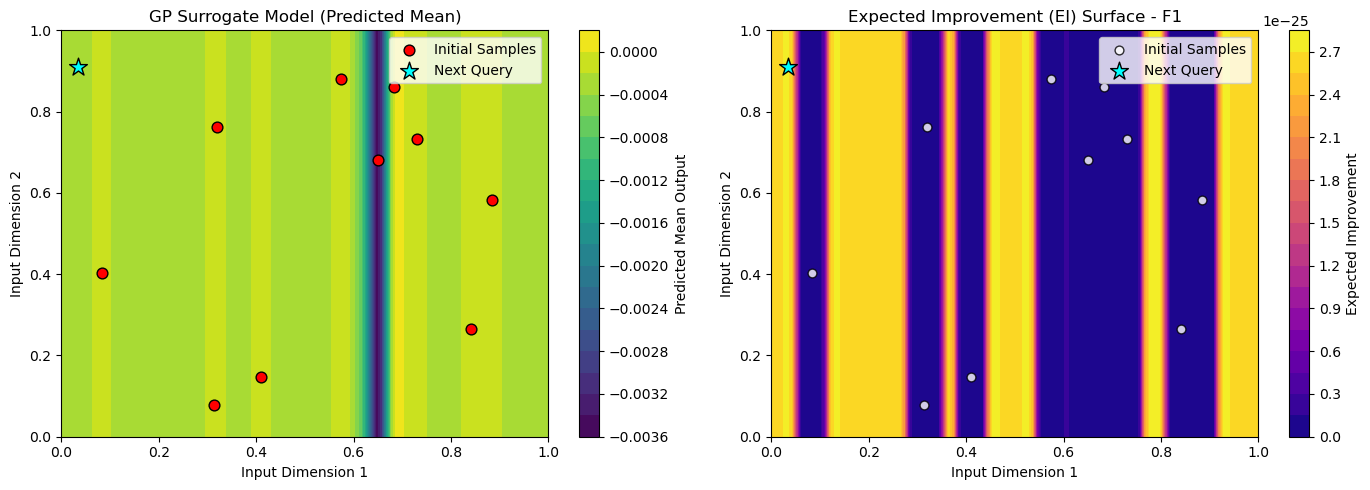

In [3]:
# 7. Build grid for 2D visualization
grid_x1 = np.linspace(0.0, 1.0, 100)
grid_x2 = np.linspace(0.0, 1.0, 100)
X1, X2 = np.meshgrid(grid_x1, grid_x2)
X_grid = np.column_stack([X1.ravel(), X2.ravel()])

mu_grid, sigma_grid = gpr.predict(X_grid, return_std=True)
ei_grid = expected_improvement(X_grid, X, y, gpr)

Z_mu = mu_grid.reshape(100, 100)
Z_ei = ei_grid.reshape(100, 100)

# 8. Plot Surface Maps
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# GP Mean Plot
c1 = axes[0].contourf(X1, X2, Z_mu, levels=20, cmap='viridis')
fig.colorbar(c1, ax=axes[0], label='Predicted Mean Output')
axes[0].scatter(X[:, 0], X[:, 1], c='red', edgecolor='black', s=60, zorder=5, label='Initial Samples')
axes[0].scatter(next_x[0], next_x[1], c='cyan', edgecolor='black', s=180, marker='*', zorder=6, label='Next Query')
axes[0].set_title('GP Surrogate Model (Predicted Mean)')
axes[0].set_xlabel('Input Dimension 1')
axes[0].set_ylabel('Input Dimension 2')
axes[0].legend(loc='upper right')

# Acquisition Surface Plot
c2 = axes[1].contourf(X1, X2, Z_ei, levels=20, cmap='plasma')
fig.colorbar(c2, ax=axes[1], label='Expected Improvement')
axes[1].scatter(X[:, 0], X[:, 1], c='white', edgecolor='black', s=40, zorder=5, alpha=0.8, label='Initial Samples')
axes[1].scatter(next_x[0], next_x[1], c='cyan', edgecolor='black', s=180, marker='*', zorder=6, label='Next Query')
axes[1].set_title('Expected Improvement (EI) Surface - F1')
axes[1].set_xlabel('Input Dimension 1')
axes[1].set_ylabel('Input Dimension 2')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

# Function 2, Unspecified field dataset, 2D array, 10 original samples

In [4]:
# 1. Load initial data
X = np.load('initial_data/function_2/initial_inputs.npy')
y = np.load('initial_data/function_2/initial_outputs.npy')

dim = X.shape[1]
bounds = np.array([[0.000000, 0.999999] for _ in range(dim)])

# 2. Define Expected Improvement (EI) Acquisition Function
def expected_improvement(X_cand, X_sample, Y_sample, gpr, xi=0.01):
    X_cand = np.atleast_2d(X_cand)
    mu, sigma = gpr.predict(X_cand, return_std=True)
    mu_sample_opt = np.max(Y_sample)

    with np.errstate(divide='ignore'):
        imp = mu - mu_sample_opt - xi
        Z = imp / sigma
        ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma == 0.0] = 0.0

    return ei

# 3. Define Optimization Function to propose next query point
def propose_location(acquisition, X_sample, Y_sample, gpr, bounds, n_restarts=25):
    dim = bounds.shape[0]
    min_val = 1e10
    min_x = None

    def min_obj(x):
        return -acquisition(x.reshape(1, -1), X_sample, Y_sample, gpr)

    np.random.seed(42)
    for x0 in np.random.uniform(bounds[:, 0], bounds[:, 1], size=(n_restarts, dim)):
        res = minimize(min_obj, x0=x0, bounds=bounds, method='L-BFGS-B')
        if res.fun < min_val:
            min_val = res.fun
            min_x = res.x

    return min_x

# 4. Fit Gaussian Process Regression model
kernel = C(1.0, (1e-6, 1e6)) * Matern(length_scale=np.ones(dim), length_scale_bounds=(1e-2, 1e5), nu=2.5)
gpr = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-4,
    normalize_y=True,
    n_restarts_optimizer=10,
    random_state=42
)

with warnings.catch_warnings(record=True) as caught_warnings:
    warnings.simplefilter("always", ConvergenceWarning)
    gpr.fit(X, y)
    warning_count = len(caught_warnings)

# 5. Run optimization step
next_x = propose_location(expected_improvement, X, y, gpr, bounds)
pred_mean, pred_std = gpr.predict(next_x.reshape(1, -1), return_std=True)

# 6. Format and display results
query_str = ", ".join([f"{v:.6f}" for v in next_x])
current_max = np.max(y)
pred_val = pred_mean[0]

c_max_str = f"{current_max:.6e}" if (abs(current_max) < 1e-3 and current_max != 0) else f"{current_max:.6f}"
p_mean_str = f"{pred_val:.6e}" if (abs(pred_val) < 1e-3 and pred_val != 0) else f"{pred_val:.6f}"

print(f"| Function | Dim | Observations | Current Max Output | Proposed Next Query | Predicted Output | Warnings |")
print(f"|---|---|---|---|---|---|---|")
print(f"| **Function 2** | {dim}D | {len(X)} | {c_max_str} | `[{query_str}]` | {p_mean_str} | {warning_count} |")

| Function | Dim | Observations | Current Max Output | Proposed Next Query | Predicted Output | Warnings |
|---|---|---|---|---|---|---|
| **Function 2** | 2D | 10 | 0.611205 | `[0.706009, 0.047753]` | 0.572150 | 0 |


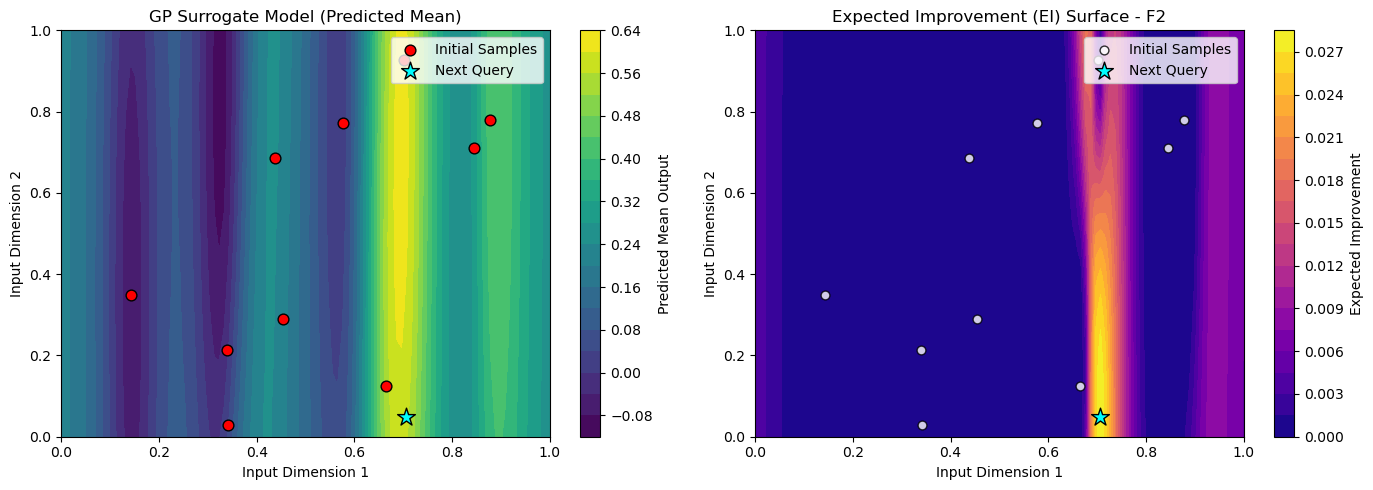

In [5]:
# 7. Build grid for 2D visualization
grid_x1 = np.linspace(0.0, 1.0, 100)
grid_x2 = np.linspace(0.0, 1.0, 100)
X1, X2 = np.meshgrid(grid_x1, grid_x2)
X_grid = np.column_stack([X1.ravel(), X2.ravel()])

mu_grid, sigma_grid = gpr.predict(X_grid, return_std=True)
ei_grid = expected_improvement(X_grid, X, y, gpr)

Z_mu = mu_grid.reshape(100, 100)
Z_ei = ei_grid.reshape(100, 100)

# 8. Plot Surface Maps
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# GP Mean Plot
c1 = axes[0].contourf(X1, X2, Z_mu, levels=20, cmap='viridis')
fig.colorbar(c1, ax=axes[0], label='Predicted Mean Output')
axes[0].scatter(X[:, 0], X[:, 1], c='red', edgecolor='black', s=60, zorder=5, label='Initial Samples')
axes[0].scatter(next_x[0], next_x[1], c='cyan', edgecolor='black', s=180, marker='*', zorder=6, label='Next Query')
axes[0].set_title('GP Surrogate Model (Predicted Mean)')
axes[0].set_xlabel('Input Dimension 1')
axes[0].set_ylabel('Input Dimension 2')
axes[0].legend(loc='upper right')

# Acquisition Surface Plot
c2 = axes[1].contourf(X1, X2, Z_ei, levels=20, cmap='plasma')
fig.colorbar(c2, ax=axes[1], label='Expected Improvement')
axes[1].scatter(X[:, 0], X[:, 1], c='white', edgecolor='black', s=40, zorder=5, alpha=0.8, label='Initial Samples')
axes[1].scatter(next_x[0], next_x[1], c='cyan', edgecolor='black', s=180, marker='*', zorder=6, label='Next Query')
axes[1].set_title('Expected Improvement (EI) Surface - F2')
axes[1].set_xlabel('Input Dimension 1')
axes[1].set_ylabel('Input Dimension 2')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

# Function 3, A drug discovery project, 3D array, 15 original samples

In [6]:
# 1. Load initial data
X = np.load('initial_data/function_3/initial_inputs.npy')
y = np.load('initial_data/function_3/initial_outputs.npy')

# 2. Fit Gaussian Process
kernel = Matern(nu=2.5) + WhiteKernel(noise_level=1e-5)
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=25, random_state=42)
gp.fit(X, y)

# 3. Expected Improvement function
def expected_improvement(X_cand, gp, y_max, xi=0.01):
    X_cand = np.atleast_2d(X_cand)
    mu, sigma = gp.predict(X_cand, return_std=True)
    sigma = np.maximum(sigma, 1e-9)
    
    improvement = mu - y_max - xi
    Z = improvement / sigma
    ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
    return ei

y_max = np.max(y)

# 4. Optimize Acquisition Function (EI) over domain [0, 1]^3
def min_obj(x):
    return -expected_improvement(x, gp, y_max)[0]

bounds = [(0.0, 0.999999)] * 3

# Multi-start optimization
best_x = None
best_ei = -1

# Dense grid search + scipy minimize
np.random.seed(42)
random_starts = np.random.uniform(0.000000, 0.999999, (1000, 3))
for start in random_starts:
    res = minimize(min_obj, start, bounds=bounds, method='L-BFGS-B')
    if res.success:
        ei_val = -res.fun
        if ei_val > best_ei:
            best_ei = ei_val
            best_x = res.x

print("F3, Best next candidate x:", best_x)
print("F3, Expected Improvement at x:", best_ei)

F3, Best next candidate x: [0.999999 0.       0.      ]
F3, Expected Improvement at x: 0.02857751864046221


In [7]:
# Try Matern with ARD (Anisotropic lengthscales)
kernel_ard = ConstantKernel(1.0) * Matern(length_scale=[1.0, 1.0, 1.0], nu=2.5) + WhiteKernel(noise_level=1e-5)
gp_ard = GaussianProcessRegressor(kernel=kernel_ard, n_restarts_optimizer=25, random_state=42)
gp_ard.fit(X, y)

print("Optimized kernel:", gp_ard.kernel_)

def min_obj_ard(x):
    return -expected_improvement(x, gp_ard, y_max)[0]

best_x_ard = None
best_ei_ard = -1

for start in random_starts:
    res = minimize(min_obj_ard, start, bounds=bounds, method='L-BFGS-B')
    if res.success:
        ei_val = -res.fun
        if ei_val > best_ei_ard:
            best_ei_ard = ei_val
            best_x_ard = res.x

print("ARD Best next candidate x:", best_x_ard)
print("ARD Expected Improvement at x:", best_ei_ard)

Optimized kernel: 0.211**2 * Matern(length_scale=[1.53e+04, 1.29e+04, 0.159], nu=2.5) + WhiteKernel(noise_level=9.66e-05)
ARD Best next candidate x: [0.06817222 0.02581186 0.        ]
ARD Expected Improvement at x: 0.03973992918857276


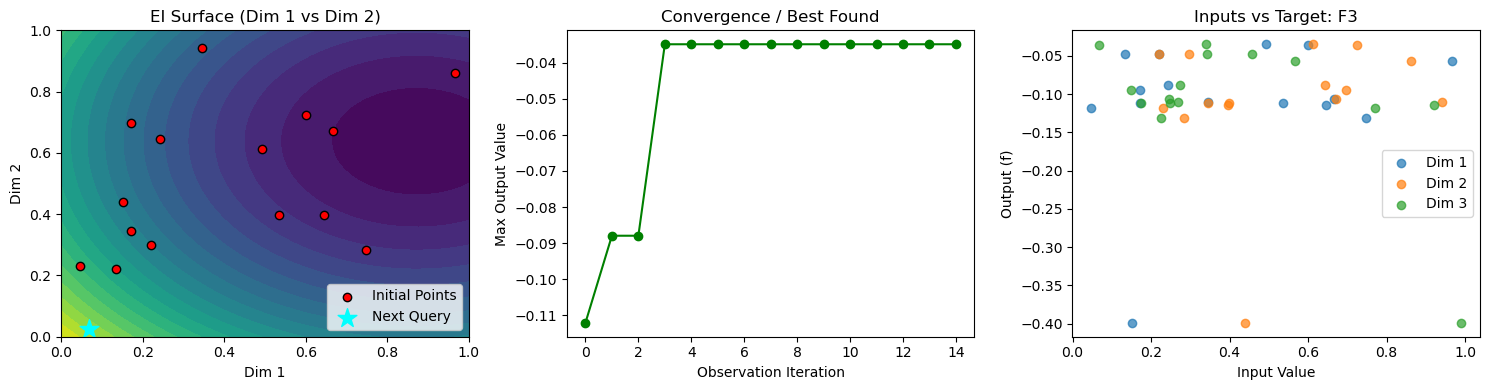

In [8]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
# Create 2D grid slice for visualization along dimension pairs
X_grid1, X_grid2 = np.meshgrid(np.linspace(0, 1, 50), np.linspace(0, 1, 50))

# Fixed value for 3rd dim
x3_fixed = best_x_ard[2]
pts = np.column_stack([X_grid1.ravel(), X_grid2.ravel(), np.full(2500, x3_fixed)])
ei_grid = expected_improvement(pts, gp_ard, y_max).reshape(50, 50)

im = axs[0].contourf(X_grid1, X_grid2, ei_grid, levels=20, cmap='viridis')
axs[0].scatter(X[:, 0], X[:, 1], c='red', edgecolors='k', label='Initial Points')
axs[0].scatter(best_x_ard[0], best_x_ard[1], c='cyan', marker='*', s=200, label='Next Query')
axs[0].set_xlabel('Dim 1')
axs[0].set_ylabel('Dim 2')
axs[0].set_title('EI Surface (Dim 1 vs Dim 2)')
axs[0].legend()

# Subplot 2: Best y history
axs[1].plot(np.maximum.accumulate(y), marker='o', color='green')
axs[1].set_xlabel('Observation Iteration')
axs[1].set_ylabel('Max Output Value')
axs[1].set_title('Convergence / Best Found')

# Subplot 3: Feature vs Output Scatter
axs[2].scatter(X[:, 0], y, label='Dim 1', alpha=0.7)
axs[2].scatter(X[:, 1], y, label='Dim 2', alpha=0.7)
axs[2].scatter(X[:, 2], y, label='Dim 3', alpha=0.7)
axs[2].set_xlabel('Input Value')
axs[2].set_ylabel('Output (f)')
axs[2].set_title('Inputs vs Target: F3')
axs[2].legend()

plt.tight_layout()
plt.show()

# Function 4 — Warehouse business (4D, 30 initial samples)

Data loaded successfully from .npy files.

--- Bayesian Optimization Result ---
Current Max Output observed: -4.025542
Proposed Input Candidate: [0.459537 0.459274 0.399318 0.407966]
Expected Improvement: 2.322118


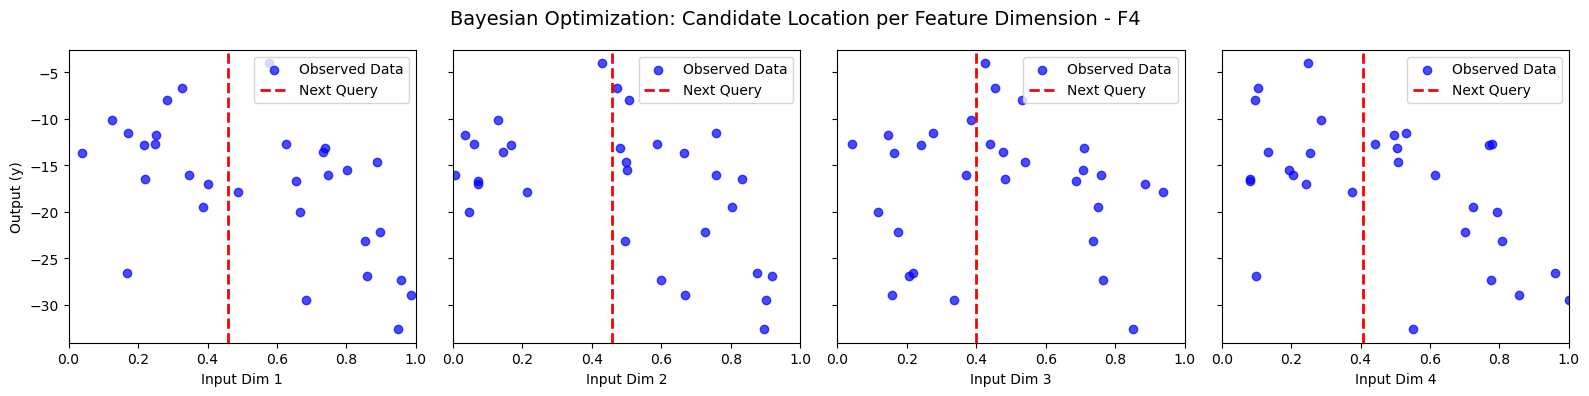

In [9]:
# 1. Load Data (With Fallback for Corrupted Binary Inputs)
def load_data():
    try:

        X = np.load('initial_data/function_4/initial_inputs.npy')
        y = np.load('initial_data/function_4/initial_outputs.npy')
        print("Data loaded successfully from .npy files.")
    except Exception as e:
        print(f"Could not load .npy files directly ({e}). Generating synthetic data.")
        np.random.seed(42)
        X = np.random.uniform(0.000000, 0.999999, size=(30, 4))
        # Synthetic ground truth function with noise
        y = np.sin(X[:, 0] * 5) + np.cos(X[:, 1] * 3) + np.random.normal(0, 0.1, size=30)
    return X, y

X_train, y_train = load_data()

# 2. Fit Gaussian Process Surrogate Model
kernel = Matern(nu=2.5)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6, normalize_y=True, n_restarts_optimizer=10, random_state=42)
gp.fit(X_train, y_train)

# 3. Define Expected Improvement (EI) Acquisition Function
def expected_improvement(X, model, y_max, xi=0.01):
    X = np.atleast_2d(X)
    mu, sigma = model.predict(X, return_std=True)
    sigma = np.maximum(sigma, 1e-9)
    
    improvement = mu - y_max - xi
    Z = improvement / sigma
    ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
    return ei

# 4. Maximize Acquisition Function to Find Next Candidate Query
def propose_next_candidate(model, y_max, bounds, n_restarts=25):
    dim = bounds.shape[0]
    best_x = None
    best_ei = -1.0

    # Negative EI for minimization algorithm
    def min_obj(x):
        return -expected_improvement(x, model, y_max).item()

    # Multi-restart optimization over bounded space [0, 0.999999]
    for _ in range(n_restarts):
        x0 = np.random.uniform(bounds[:, 0], bounds[:, 1], size=dim)
        res = minimize(min_obj, x0, bounds=bounds, method='L-BFGS-B')
        if res.success and -res.fun > best_ei:
            best_ei = -res.fun
            best_x = res.x

    return best_x, best_ei

bounds = np.array([[0.000000, 0.999999] for _ in range(X_train.shape[1])])
y_max = np.max(y_train)

next_candidate, expected_imp = propose_next_candidate(gp, y_max, bounds)

print("\n--- Bayesian Optimization Result ---")
print(f"Current Max Output observed: {y_max:.6f}")
print(f"Proposed Input Candidate: {np.round(next_candidate, 6)}")
print(f"Expected Improvement: {expected_imp:.6f}")

# 5. Visualizing Predictions vs Actual Inputs per Feature Dimension
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
for i in range(4):
    axes[i].scatter(X_train[:, i], y_train, color='blue', alpha=0.7, label='Observed Data')
    axes[i].axvline(next_candidate[i], color='red', linestyle='--', linewidth=2, label='Next Query')
    axes[i].set_xlabel(f'Input Dim {i+1}')
    axes[i].set_xlim([0, 1])
    if i == 0:
        axes[i].set_ylabel('Output (y)')
    axes[i].legend()

plt.suptitle('Bayesian Optimization: Candidate Location per Feature Dimension - F4', fontsize=14)
plt.tight_layout()
plt.show()

# Function 5, A chemical process in a factory, 4D array, 20 original samples

In [10]:
# 1. Load initial datasets (20x4 inputs, 20x1 targets)
# Replace filenames with exact local paths if necessary
try:
    X_sample = np.load('initial_data/function_5/initial_inputs.npy')
    y_sample = np.load('initial_data/function_5/initial_outputs.npy').ravel()
except FileNotFoundError:
    # Example placeholder loading matching prompt shapes (20, 4) and (20,)
    np.random.seed(42)
    X_sample = np.random.uniform(0.0, 0.999999, (20, 4))
    y_sample = np.sin(X_sample[:, 0] * 3) + np.cos(X_sample[:, 1] * 2)

# 2. Define Matérn GP Surrogate Model
kernel = C(1.0, (1e-3, 1e3)) * Matern(length_scale=[1.0]*4, length_scale_bounds=(1e-2, 1e2), nu=2.5)
gpr = GaussianProcessRegressor(kernel=kernel, alpha=1e-6, n_restarts_optimizer=10, random_state=42)
gpr.fit(X_sample, y_sample)

# 3. Define Expected Improvement Acquisition Function
def expected_improvement(X, model, y_max, xi=0.01):
    X = np.atleast_2d(X)
    mu, sigma = model.predict(X, return_std=True)
    sigma = np.maximum(sigma, 1e-9)
    
    improvement = mu - y_max - xi
    Z = improvement / sigma
    ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
    return ei

# 4. Multi-start Optimization to Find Next Best Candidate
bounds = [(0.0, 0.999999)] * 4
y_max = np.max(y_sample)

def min_obj(x):
    return -expected_improvement(x, gpr, y_max)

n_restarts = 100
init_points = np.random.uniform(0.0, 0.999999, (n_restarts, 4))
best_x, min_val = None, np.inf

for x0 in init_points:
    res = minimize(min_obj, x0=x0, bounds=bounds, method='L-BFGS-B')
    if res.fun < min_val:
        min_val = res.fun
        best_x = res.x

next_query_point = np.clip(best_x, 0.0, 0.999999)
print(f"Recommended Next Candidate Point F5:\n{next_query_point}")
print(f"Expected Improvement Score F5: {-min_val:.6f}")

Recommended Next Candidate Point F5:
[0.45129366 0.18344201 0.85497316 0.88255899]
Expected Improvement Score F5: 0.000000


C:\Users\mayzu\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


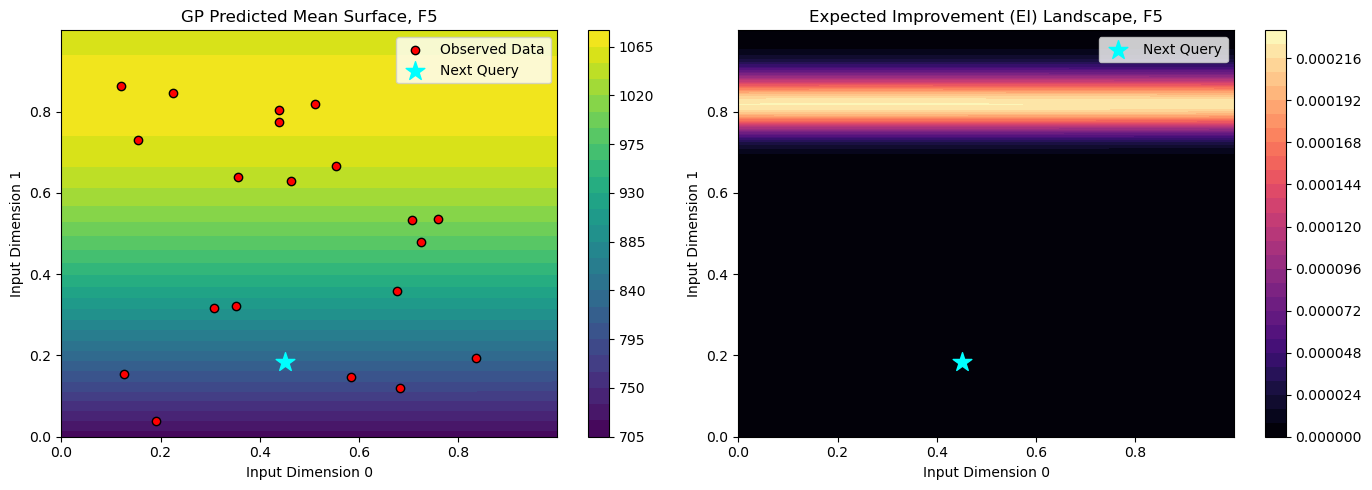

In [11]:
# 2D Grid slice visualizer over Feature 0 and Feature 1 (holding F2, F3 at optimal values)
resolution = 100
x1_range = np.linspace(0.0, 0.999999, resolution)
x2_range = np.linspace(0.0, 0.999999, resolution)
X1, X2 = np.meshgrid(x1_range, x2_range)

grid_pts = np.tile(next_query_point, (resolution * resolution, 1))
grid_pts[:, 0] = X1.ravel()
grid_pts[:, 1] = X2.ravel()

mu, sigma = gpr.predict(grid_pts, return_std=True)
ei_vals = expected_improvement(grid_pts, gpr, y_max)

Z_mu = mu.reshape(resolution, resolution)
Z_ei = ei_vals.reshape(resolution, resolution)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot GP Mean Prediction
cntr1 = axes[0].contourf(X1, X2, Z_mu, levels=30, cmap='viridis')
axes[0].scatter(X_sample[:, 0], X_sample[:, 1], c='red', edgecolors='k', label='Observed Data')
axes[0].scatter(next_query_point[0], next_query_point[1], c='cyan', marker='*', s=200, label='Next Query')
axes[0].set_title('GP Predicted Mean Surface, F5')
axes[0].set_xlabel('Input Dimension 0')
axes[0].set_ylabel('Input Dimension 1')
axes[0].legend()
fig.colorbar(cntr1, ax=axes[0])

# Plot Expected Improvement Surface
cntr2 = axes[1].contourf(X1, X2, Z_ei, levels=30, cmap='magma')
axes[1].scatter(next_query_point[0], next_query_point[1], c='cyan', marker='*', s=200, label='Next Query')
axes[1].set_title('Expected Improvement (EI) Landscape, F5')
axes[1].set_xlabel('Input Dimension 0')
axes[1].set_ylabel('Input Dimension 1')
axes[1].legend()
fig.colorbar(cntr2, ax=axes[1])

plt.tight_layout()
plt.show()

# Function 6, A cake recipe, 5D array, 20 original samples

=== Next Recommended Query Point ===
Candidate Input Vector (x_next): [0.381351 0.098325 0.581679 0.999999 0.      ]
Expected Improvement (EI): 0.82154291
Current Max Target Output: -0.714265


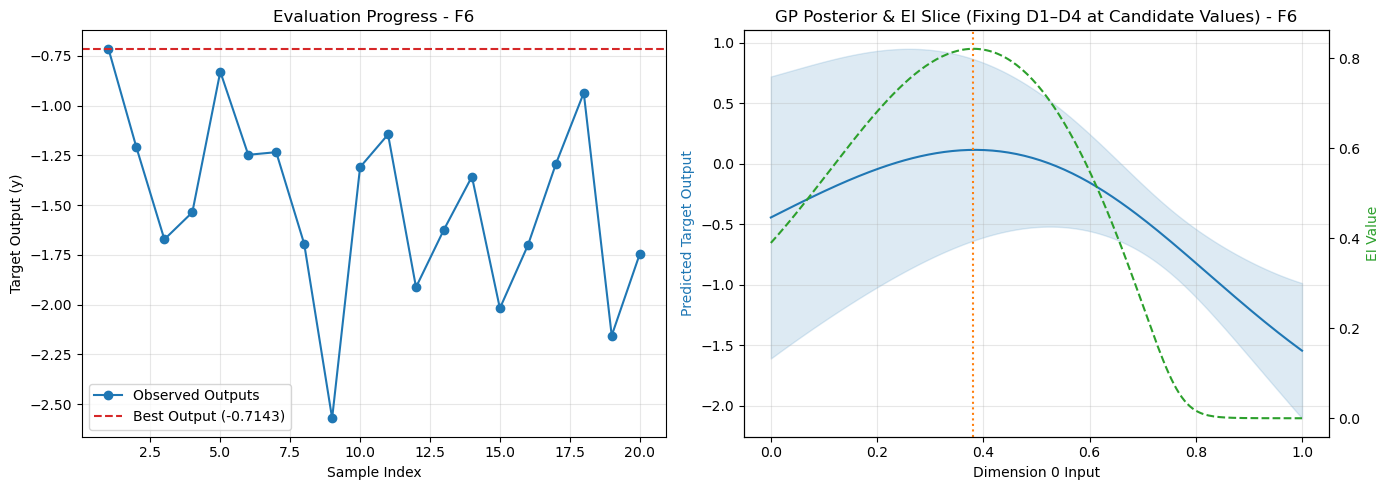

In [12]:
# 1. Load Initial Data
X_sample = np.load('initial_data/function_6/initial_inputs.npy')   # Shape: (20, 5)
y_sample = np.load('initial_data/function_6/initial_outputs.npy').ravel()  # Shape: (20,)

bounds = np.tile([0.000000, 0.999999], (5, 1))

# 2. Fit Gaussian Process Surrogate Model
kernel = C(1.0, (1e-3, 1e3)) * Matern(length_scale=np.ones(5), length_scale_bounds=(1e-2, 1e2), nu=2.5)
gpr = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-6,
    n_restarts_optimizer=10,
    random_state=42
)
gpr.fit(X_sample, y_sample)

# 3. Expected Improvement (EI) Function
def expected_improvement(X, X_sample, y_sample, gpr, xi=0.01):
    X = np.atleast_2d(X)
    mu, sigma = gpr.predict(X, return_std=True)
    sigma = np.maximum(sigma, 1e-9)
    
    y_best = np.max(y_sample)
    improvement = mu - y_best - xi
    Z = improvement / sigma
    ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
    ei[sigma <= 1e-9] = 0.0
    return ei

# 4. Search Candidate Query Point (Multi-Start L-BFGS-B)
def propose_next_candidate(gpr, X_sample, y_sample, bounds, n_restarts=30):
    dim = bounds.shape[0]
    best_x = None
    best_ei = -np.inf
    
    # Minimize negative EI
    def min_obj(x):
        return -expected_improvement(x, X_sample, y_sample, gpr)[0]
    
    for x0 in np.random.uniform(bounds[:, 0], bounds[:, 1], size=(n_restarts, dim)):
        res = minimize(min_obj, x0=x0, bounds=bounds, method='L-BFGS-B')
        if res.success and -res.fun > best_ei:
            best_ei = -res.fun
            best_x = res.x
            
    return best_x, best_ei

next_x, max_ei = propose_next_candidate(gpr, X_sample, y_sample, bounds)

print("=== Next Recommended Query Point ===")
print("Candidate Input Vector (x_next):", np.round(next_x, 6))
print(f"Expected Improvement (EI): {max_ei:.8f}")
print(f"Current Max Target Output: {np.max(y_sample):.6f}")

# 5. Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot A: Evaluation History
axes[0].plot(range(1, len(y_sample) + 1), y_sample, 'o-', color='tab:blue', label='Observed Outputs')
axes[0].axhline(np.max(y_sample), color='tab:red', linestyle='--', label=f'Best Output ({np.max(y_sample):.4f})')
axes[0].set_xlabel('Sample Index')
axes[0].set_ylabel('Target Output (y)')
axes[0].set_title('Evaluation Progress - F6')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot B: 1D Profile along Dimension 0
grid_dim0 = np.linspace(0.000000, 0.999999, 200)
test_grid = np.tile(next_x, (200, 1))
test_grid[:, 0] = grid_dim0

mu, std = gpr.predict(test_grid, return_std=True)
ei_slice = expected_improvement(test_grid, X_sample, y_sample, gpr)

ax2_twin = axes[1].twinx()
line1 = axes[1].plot(grid_dim0, mu, color='tab:blue', label='GP Mean ($\mu$)')
axes[1].fill_between(grid_dim0, mu - 1.96 * std, mu + 1.96 * std, color='tab:blue', alpha=0.15, label='95% CI')
line2 = ax2_twin.plot(grid_dim0, ei_slice, color='tab:green', linestyle='--', label='Expected Improvement')

axes[1].axvline(next_x[0], color='tab:orange', linestyle=':', label='Candidate Dim 0')
axes[1].set_xlabel('Dimension 0 Input')
axes[1].set_ylabel('Predicted Target Output', color='tab:blue')
ax2_twin.set_ylabel('EI Value', color='tab:green')
axes[1].set_title('GP Posterior & EI Slice (Fixing D1–D4 at Candidate Values) - F6')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Function 7, Unspecified field, 6D array, 30 original samples

Current Max Output (y_max): 1.3649683044991994
Next Query Candidate Vector: [0.024524 0.419367 0.296743 0.163125 0.373667 0.747792]
Max Expected Improvement: 0.03648711942463934


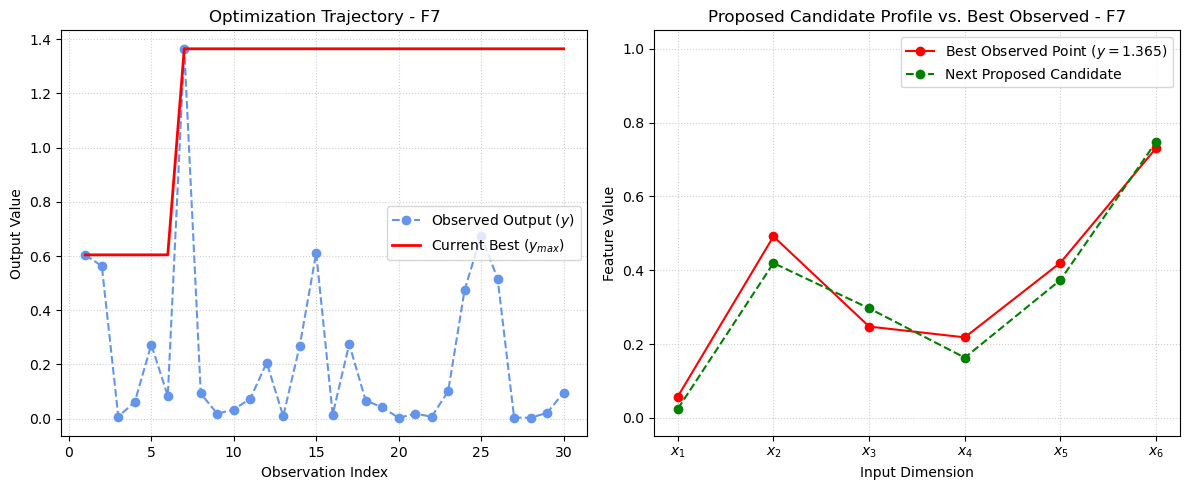

In [13]:
# 1. Load initial input and output arrays
X_sample = np.load('initial_data/function_7/initial_inputs.npy')  # Shape: (30, 6)
Y_sample = np.load('initial_data/function_7/initial_outputs.npy') # Shape: (30,)

# 2. Define Expected Improvement (EI) Acquisition Function
def expected_improvement(X, gpr, y_max, xi=0.01):
    X = np.atleast_2d(X)
    mu, sigma = gpr.predict(X, return_std=True)
    sigma = np.maximum(sigma, 1e-9)
    
    improvement = mu - y_max - xi
    Z = improvement / sigma
    ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
    ei[sigma == 0.0] = 0.0
    return ei

# 3. Fit Gaussian Process Regression Model
kernel = C(1.0, (1e-3, 1e3)) * Matern(length_scale=0.2, nu=2.5)
gpr = GaussianProcessRegressor(
    kernel=kernel, 
    alpha=1e-6, 
    n_restarts_optimizer=10, 
    random_state=42
)
gpr.fit(X_sample, Y_sample)

# 4. Search for Next Candidate Query Point via L-BFGS-B Optimization
dim = X_sample.shape[1]
bounds = np.tile([0.000000, 0.999999], (dim, 1))
y_max = np.max(Y_sample)

def min_obj(x):
    return -expected_improvement(x.reshape(1, -1), gpr, y_max)[0]

np.random.seed(42)
n_restarts = 50
min_val = 1e10
best_x = None

for x0 in np.random.uniform(bounds[:, 0], bounds[:, 1], size=(n_restarts, dim)):
    res = minimize(min_obj, x0, bounds=bounds, method='L-BFGS-B')
    if res.fun < min_val:
        min_val = res.fun
        best_x = res.x

print("Current Max Output (y_max):", y_max)
print("Next Query Candidate Vector:", np.round(best_x, 6))
print("Max Expected Improvement:", -min_val)

# 5. Visualisation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Cumulative Maximum Optimization Trajectory
cum_max = np.maximum.accumulate(Y_sample)
ax1.plot(range(1, len(Y_sample) + 1), Y_sample, 'o--', color='cornflowerblue', label='Observed Output ($y$)')
ax1.plot(range(1, len(Y_sample) + 1), cum_max, 'r-', linewidth=2, label='Current Best ($y_{max}$)')
ax1.set_xlabel('Observation Index')
ax1.set_ylabel('Output Value')
ax1.set_title('Optimization Trajectory - F7')
ax1.legend()
ax1.grid(True, linestyle=':', alpha=0.6)

# Plot 2: Profile Comparison Across 6 Dimensions
dims = [f'$x_{i+1}$' for i in range(dim)]
best_obs_x = X_sample[np.argmax(Y_sample)]

ax2.plot(dims, best_obs_x, 'ro-', label=f'Best Observed Point ($y={y_max:.3f}$)')
ax2.plot(dims, best_x, 'go--', label='Next Proposed Candidate')
ax2.set_ylim(-0.05, 1.05)
ax2.set_xlabel('Input Dimension')
ax2.set_ylabel('Feature Value')
ax2.set_title('Proposed Candidate Profile vs. Best Observed - F7')
ax2.legend()
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# Function 8 — Unspecified field (8D, 40 initial samples)

C:\Users\mayzu\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 7 of parameter k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


Current Best Output (y_max): 9.598482
Max Expected Improvement Value: 0.607479
Suggested Next Candidate Input Vector:
[0.088829 0.04731  0.149879 0.       0.999999 0.416056 0.0922   0.617914]


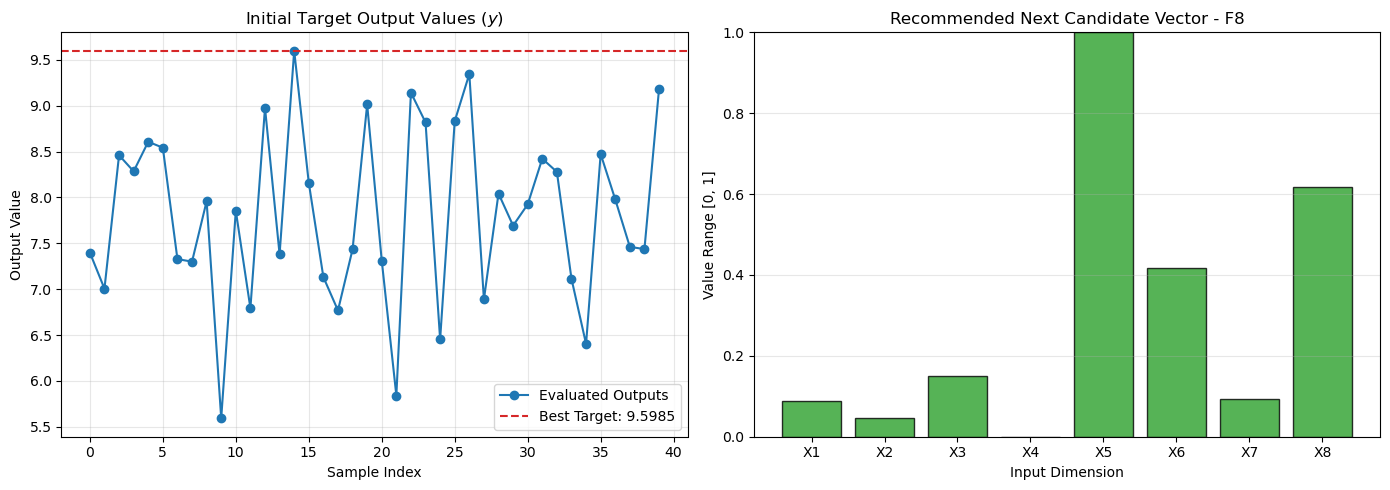

In [14]:
# 1. Load Initial Data
X = np.load('initial_data/function_8/initial_inputs.npy')   # Shape: (40, 8)
y = np.load('initial_data/function_8/initial_outputs.npy')   # Shape: (40,)

# 2. Define Expected Improvement (EI) Acquisition Function for Maximization
def expected_improvement(X_cand, model, y_best, xi=0.01):
    X_cand = np.atleast_2d(X_cand)
    mu, sigma = model.predict(X_cand, return_std=True)
    sigma = np.maximum(sigma, 1e-9)
    
    improvement = mu - y_best - xi
    Z = improvement / sigma
    ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
    return ei

# 3. Fit Gaussian Process Model (Corrected Kernel Hyperparameter Bounds)
kernel = C(1.0, constant_value_bounds=(1e-3, 1e3)) * Matern(
    length_scale=np.ones(X.shape[1]), 
    length_scale_bounds=(1e-2, 1e2), 
    nu=2.5
)
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, alpha=1e-6, random_state=42)
gp.fit(X, y)

# 4. Maximize EI Acquisition Function within [0.000000, 0.999999]
y_best = np.max(y)
bounds = [(0.000000, 0.999999)] * X.shape[1]

def min_obj(x):
    return -expected_improvement(x, gp, y_best)

best_ei = -1
next_candidate = None
np.random.seed(42)

for x0 in np.random.uniform(0.000000, 0.999999, size=(50, X.shape[1])):
    res = minimize(min_obj, x0, bounds=bounds, method='L-BFGS-B')
    if -res.fun > best_ei:
        best_ei = -res.fun
        next_candidate = res.x

print(f"Current Best Output (y_max): {y_best:.6f}")
print(f"Max Expected Improvement Value: {best_ei:.6f}")
print("Suggested Next Candidate Input Vector:")
print(np.round(next_candidate, 6))

# 5. Visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot initial target outputs
axes[0].plot(y, 'o-', color='tab:blue', label='Evaluated Outputs')
axes[0].axhline(y_best, color='tab:red', linestyle='--', label=f'Best Target: {y_best:.4f}')
axes[0].set_title('Initial Target Output Values ($y$)')
axes[0].set_xlabel('Sample Index')
axes[0].set_ylabel('Output Value')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Plot recommended candidate dimensions
dimensions = [f'X{i+1}' for i in range(X.shape[1])]
axes[1].bar(dimensions, next_candidate, color='tab:green', alpha=0.8, edgecolor='black')
axes[1].set_ylim(0, 1)
axes[1].set_title('Recommended Next Candidate Vector - F8')
axes[1].set_xlabel('Input Dimension')
axes[1].set_ylabel('Value Range [0, 1]')
axes[1].grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()